In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())


cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Scale-up I/O Bandwidth Target Sweep

**Question:** what scale-up I/O bandwidth do you actually need to keep collective communication below a chosen fraction of *t*<sub>mem</sub> (e.g. *f* = 10%) — across (model, sharding, batch size)?

**Approach:** evaluate the closed-form *BW*<sub>target</sub>(*f*, *B*) = *b*<sub>p</sub>(*B*) / (*f* · *t*<sub>mem</sub>(*B*) − *a*<sub>p</sub> · α) derived in [`documentation/explaining/scale_up_io_break_even.md`](../documentation/explaining/scale_up_io_break_even.md). The two partition coefficients *a*<sub>p</sub>, *b*<sub>p</sub>(*B*) plus the per-device *T*<sub>θ</sub>, *T*<sub>KV</sub> are computed directly from the model + partition specs.

**Defaults:** α = 0.2 μs, *BW*<sub>mem</sub> = 8 TB/s (HBM3e), *S* = 8192, ring algorithms (no INC). Edit the `## 2. Knobs` cell to study a different regime — including modeling INC by reducing the effective `n_TP` or `n_EP` per-call counts.

**Models studied:** GPT-1.8T MoE FP4 (attention-heavy, 16 experts × *k*=2), DeepSeek-R1 FP4 (MoE-FFN-heavy, 256 experts × *k*=9), Llama-3.1-70B FP4 (dense GQA reference).

**Output:** two plots
1. *BW*<sub>target</sub> vs *B*, one panel per model, one curve per partition shape.
2. *t*<sub>β</sub> / *t*<sub>step,user</sub> vs *B* — the marginal-sensitivity ratio from §7 of the explainer; shows directly what fraction of TPOT a BW doubling can shave.


## 1. Closed-form formulas

Lifted verbatim from `decode.md §2.1 / §2.3` (the per-device *T*<sub>θ</sub> and *T*<sub>KV</sub>) and the explainer §2 (the *a*<sub>p</sub>, *b*<sub>p</sub> partition coefficients).


In [2]:
from copy import deepcopy
from dataclasses import dataclass
import math
import matplotlib.pyplot as plt
import numpy as np

from llm_perf.io import load_model_spec
from llm_perf.specs.partition_spec import PartitionSpec


def per_device_T_theta(model, p):
    """Per-device weight read bytes (decode.md §2.1 / explainer §3)."""
    L = model.L; H = model.H; H_kv = model.H_kv()
    PP = max(1, p.PP); TP = max(1, p.TP); b = model.bytes_per_param
    if model.moe is not None:
        L_moe = model.moe.n_moe_layers if model.moe.n_moe_layers else L
        L_dense = L - L_moe
        N_exp = max(1, model.moe.n_experts); I_moe = model.moe.I_moe
        EP = max(1, p.EP)
    else:
        L_dense = L; L_moe = 0; N_exp = 0; I_moe = 0; EP = 1
    I_dense = model.I_dense
    dense = (L_dense / PP) * ((2*H**2 + 2*H*H_kv) / TP + (3*H*I_dense) / TP) * b
    moe = 0.0
    if L_moe > 0:
        moe = (L_moe / PP) * ((2*H**2 + 2*H*H_kv) / TP + (3*H*I_moe*N_exp) / (TP*EP)) * b
    return dense + moe


def per_request_T_KV(model, p, S):
    """Per-request KV cache bytes (decode.md §2.3)."""
    L = model.L; H_kv = model.H_kv()
    PP = max(1, p.PP); TP = max(1, p.TP); SP = max(1, p.SP); b = model.bytes_per_param
    return (L / PP) * (2 * S * H_kv) / (TP * SP) * b


def a_p_coef(model, p, n_TP, n_EP, n_SP):
    """α-side partition coefficient (explainer §2). Pure ring algorithms."""
    L = model.L; PP = max(1, p.PP)
    G_TP = max(1, p.TP); G_EP = max(1, p.EP); G_SP = max(1, p.SP)
    L_moe = (model.moe.n_moe_layers if model.moe and model.moe.n_moe_layers else L) if model.moe else 0
    a_TP = (L/PP) * n_TP * 2*(G_TP - 1) if G_TP > 1 else 0.0
    a_EP = (L_moe/PP) * n_EP * 2*(G_EP - 1) if G_EP > 1 else 0.0
    a_SP = (L/PP) * n_SP * (G_SP - 1) if G_SP > 1 else 0.0
    a_PP = 1.0 if PP > 1 else 0.0
    return a_TP + a_EP + a_SP + a_PP


def b_p_coef(model, p, B, n_TP, n_EP, n_SP, S):
    """β-side partition coefficient (bytes) at batch B (explainer §2). Pure ring."""
    L = model.L; H = model.H; H_kv = model.H_kv()
    PP = max(1, p.PP)
    G_TP = max(1, p.TP); G_EP = max(1, p.EP); G_SP = max(1, p.SP)
    b = model.bytes_per_param
    L_moe = (model.moe.n_moe_layers if model.moe and model.moe.n_moe_layers else L) if model.moe else 0
    k = model.moe.k_active if model.moe else 1
    b_TP = (L/PP) * n_TP * (2*(G_TP-1)/G_TP) * B * H * b if G_TP > 1 else 0.0
    b_EP = (L_moe/PP) * n_EP * (2*(G_EP-1)/G_EP) * B * k * H * b if G_EP > 1 else 0.0
    b_SP = (L/PP) * n_SP * ((G_SP-1)/G_SP) * B * S * (2 * H_kv / G_TP) * b if G_SP > 1 else 0.0
    b_PP = B * (H / G_TP) * b if PP > 1 else 0.0
    return b_TP + b_EP + b_SP + b_PP


def is_feasible(model, p):
    if p.TP > model.n_kv:
        return False
    if model.moe is not None and p.EP > model.moe.n_experts:
        return False
    return True


def bw_target(model, p, B, f, alpha_us, BW_mem_GBps, S, n_TP, n_EP, n_SP):
    """BW_target in GB/s. Returns NaN if unreachable (denominator non-positive)."""
    T_theta = per_device_T_theta(model, p)
    T_kv = per_request_T_KV(model, p, S)
    a = a_p_coef(model, p, n_TP, n_EP, n_SP)
    b_bytes = b_p_coef(model, p, B, n_TP, n_EP, n_SP, S)
    t_mem_us = (T_theta + B * T_kv) / (BW_mem_GBps * 1e9) * 1e6
    t_alpha_us = a * alpha_us
    denom_us = f * t_mem_us - t_alpha_us
    if denom_us <= 0:
        return float("nan")
    return (b_bytes / (denom_us * 1e-6)) / 1e9


## 2. Knobs

Edit these to study different regimes. The defaults are NVL5 / GB200-class scale-up with HBM3e memory. To model in-network collectives (NVLS / SHARP), reduce the per-call counts (e.g. set `N_TP_CALLS_AR = 2` for the kernel-launch count but use a separate effective `n_α` of ~2 in the formulas — easier path: monkey-patch `a_p_coef` to use the INC `n_α = 2k` form for the TP axis).


In [3]:
ALPHA_US = 0.2                   # per-tier α (NVL5 / SHARP-class, μs)
BW_MEM_GBps = 8000.0             # HBM3e on B200/GB200 (GB/s)
S_DECODE = 8192                  # decode context length
N_TP_CALLS = 2                   # NCCL AR per layer (attn + MLP)
N_EP_CALLS = 2                   # Dispatch + Combine per MoE layer
N_SP_CALLS = 1                   # Ring AG per layer
F_TARGETS = [0.10, 0.25]         # design targets t_comm ≤ f · t_mem
BATCH_SIZES = np.unique(np.round(np.logspace(0, math.log10(2048), 16)).astype(int))

REFERENCE_BW_LINES_GBps = {
    "NVLink5 (900)": 900.0,
    "NVLink4 (450)": 450.0,
    "PCIe5 x16 (64)": 64.0,
}

MODELS = [
    ("GPT-1.8T-MoE FP4",  "llm_perf/database/model/gpt_1_8t_moe.json",     0.5),
    ("DeepSeek-R1 FP4",   "llm_perf/database/model/deepseek_r1_0528.json", 0.5),
    ("Llama-3.1-70B FP4", "llm_perf/database/model/llama3.1_70b.json",     0.5),
]

# All partitions cap PP <= 8 — typical PP-capped operational regime where
# bubble cost or layer-count dominates the latency budget. The PP=32 winner
# shapes from the unbounded-PP sweeps live in `pareto_basic.ipynb` etc.
PARTITIONS = [
    ("PP=8  TP=2  EP=1  SP=1",  PartitionSpec(PP=8,  TP=2,  EP=1,  SP=1)),
    ("PP=8  TP=8  EP=1  SP=1",  PartitionSpec(PP=8,  TP=8,  EP=1,  SP=1)),
    ("PP=4  TP=16 EP=1  SP=1",  PartitionSpec(PP=4,  TP=16, EP=1,  SP=1)),
    ("PP=8  TP=4  EP=4  SP=1",  PartitionSpec(PP=8,  TP=4,  EP=4,  SP=1)),
    ("PP=8  TP=4  EP=16 SP=1",  PartitionSpec(PP=8,  TP=4,  EP=16, SP=1)),
    ("PP=8  TP=2  EP=1  SP=4",  PartitionSpec(PP=8,  TP=2,  EP=1,  SP=4)),
]

PARTITION_COLORS = plt.get_cmap("tab10").colors

print(f"Configured: α={ALPHA_US} μs, BW_mem={BW_MEM_GBps:.0f} GB/s, S={S_DECODE}")
print(f"Batch sizes ({len(BATCH_SIZES)}): {list(BATCH_SIZES)}")


Configured: α=0.2 μs, BW_mem=8000 GB/s, S=8192
Batch sizes (16): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(8), np.int64(13), np.int64(21), np.int64(35), np.int64(58), np.int64(97), np.int64(161), np.int64(268), np.int64(446), np.int64(741), np.int64(1232), np.int64(2048)]


## 3. Sweep

For each (model, partition) pair, compute *BW*<sub>target</sub>(*f*, *B*) for the configured *f* values across the batch-size ladder. Infeasible partitions (TP > *n*<sub>kv</sub>, EP > *n*<sub>exp</sub>) are skipped per model.


In [4]:
def sweep_for_model(model, n_TP, n_EP, n_SP):
    """Returns: dict[partition_label] -> dict[f] -> array of BW_target (GB/s) per B."""
    out = {}
    for plabel, p in PARTITIONS:
        if not is_feasible(model, p):
            continue
        out[plabel] = {}
        for f in F_TARGETS:
            bw_t = np.array([bw_target(model, p, int(B), f, ALPHA_US, BW_MEM_GBps,
                                       S_DECODE, n_TP, n_EP, n_SP)
                             for B in BATCH_SIZES])
            out[plabel][f] = bw_t
    return out


loaded_models = []
for name, path, b_override in MODELS:
    try:
        m = load_model_spec(path)
        if b_override is not None:
            m.bytes_per_param = b_override
        loaded_models.append((name, m))
    except FileNotFoundError:
        print(f"[skip] {path} not found")

results = {}
for name, model in loaded_models:
    results[name] = sweep_for_model(model, N_TP_CALLS, N_EP_CALLS, N_SP_CALLS)
    print(f"  {name}: {len(results[name])} feasible partitions")


  GPT-1.8T-MoE FP4: 6 feasible partitions
  DeepSeek-R1 FP4: 4 feasible partitions
  Llama-3.1-70B FP4: 5 feasible partitions


## 4. Plot — *BW*<sub>target</sub> vs batch size

One panel per model. Each panel overlays the partitions in different colors. Solid line = *f* = 0.1 (aggressive), dashed line = *f* = 0.25 (relaxed). Reference horizontal lines mark common scale-up fabric BWs (NVL5 = 900 GB/s, NVL4 = 450 GB/s, PCIe5 x16 = 64 GB/s) — anywhere a curve sits *below* a reference line, that fabric meets the target.


Saved -> assets/scale_up_io_bw_target_vs_B.png


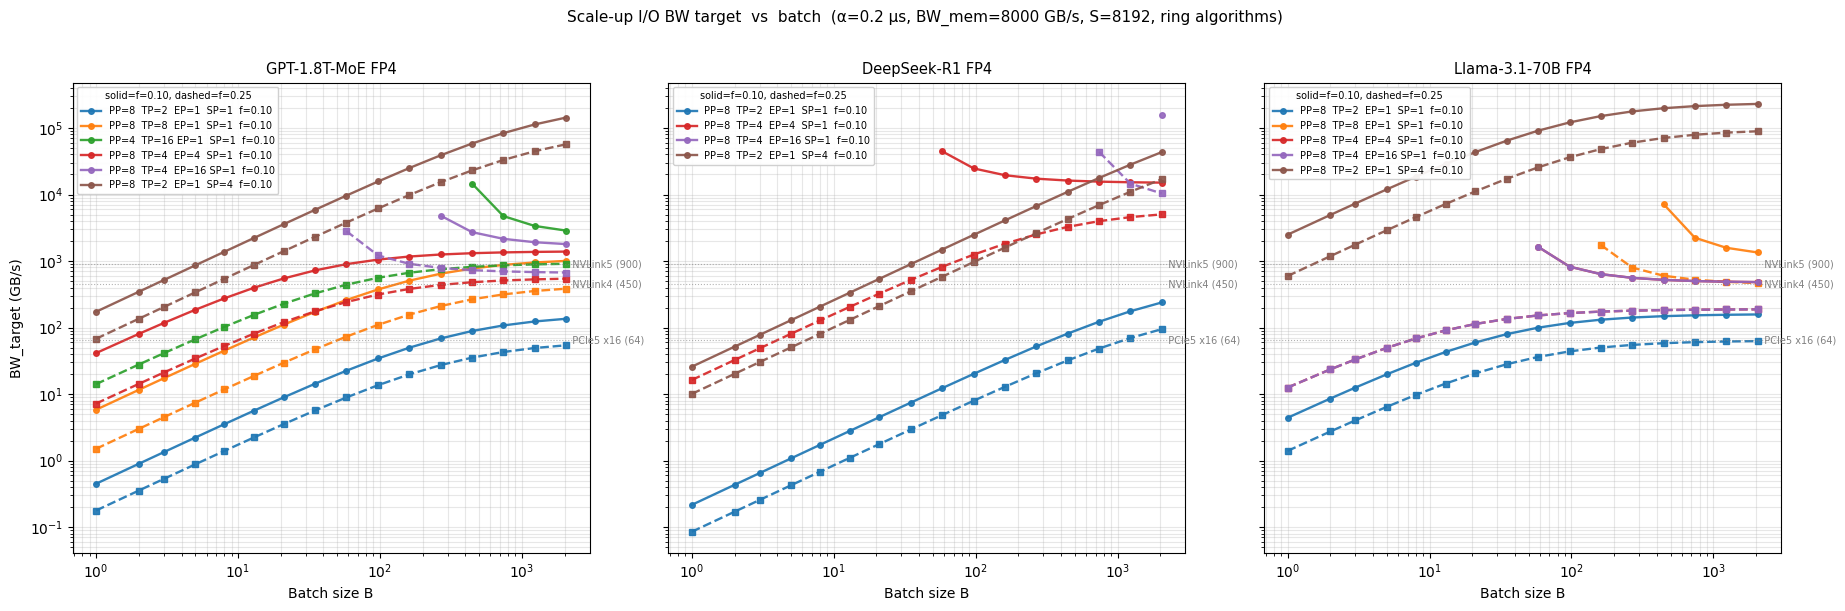

In [5]:
fig, axes = plt.subplots(1, len(loaded_models), figsize=(6.2 * len(loaded_models), 6.0),
                          sharey=True)
if len(loaded_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, loaded_models):
    res = results[name]
    for color_idx, (plabel, p) in enumerate(PARTITIONS):
        if plabel not in res:
            continue
        color = PARTITION_COLORS[color_idx % len(PARTITION_COLORS)]
        for ls, f in zip(["-", "--"], F_TARGETS):
            bw_t = res[plabel][f]
            mask = ~np.isnan(bw_t)
            label = f"{plabel}  f={f:.2f}" if f == F_TARGETS[0] else None
            ax.plot(BATCH_SIZES[mask], bw_t[mask], ls, color=color,
                    lw=1.7, marker="o" if ls == "-" else "s", ms=4,
                    alpha=0.92, label=label)
    for ref_label, ref_bw in REFERENCE_BW_LINES_GBps.items():
        ax.axhline(ref_bw, color="gray", lw=0.8, ls=":", alpha=0.6)
        ax.text(BATCH_SIZES[-1], ref_bw, f"  {ref_label}", color="gray",
                fontsize=7, va="center", ha="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Batch size B")
    ax.set_title(name, fontsize=10.5)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left", fontsize=7, framealpha=0.92,
              title=f"solid=f={F_TARGETS[0]:.2f}, dashed=f={F_TARGETS[1]:.2f}",
              title_fontsize=7)

axes[0].set_ylabel("BW_target (GB/s)")
fig.suptitle(
    f"Scale-up I/O BW target  vs  batch  (α={ALPHA_US:.1f} μs, BW_mem={BW_MEM_GBps:.0f} GB/s, "
    f"S={S_DECODE}, ring algorithms)",
    fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("assets/scale_up_io_bw_target_vs_B.png", dpi=140, bbox_inches="tight")
print("Saved -> assets/scale_up_io_bw_target_vs_B.png")
plt.show()


## 5. Plot — *t*<sub>β</sub> / *t*<sub>step,user</sub> sensitivity

The marginal-sensitivity formula from explainer §7: doubling BW shaves *t*<sub>β</sub>/(2 · *t*<sub>step,user</sub>) off TPOT in the unhidden regime. Here we plot the **share of *t*<sub>step,user</sub> that is β-side comm** (= *t*<sub>β</sub>/*t*<sub>step,user</sub> at ρ=0) so you can read the BW-doubling savings directly: a 10% line means doubling BW saves up to 5% TPOT.


Saved -> assets/scale_up_io_bw_target_t_beta_share.png


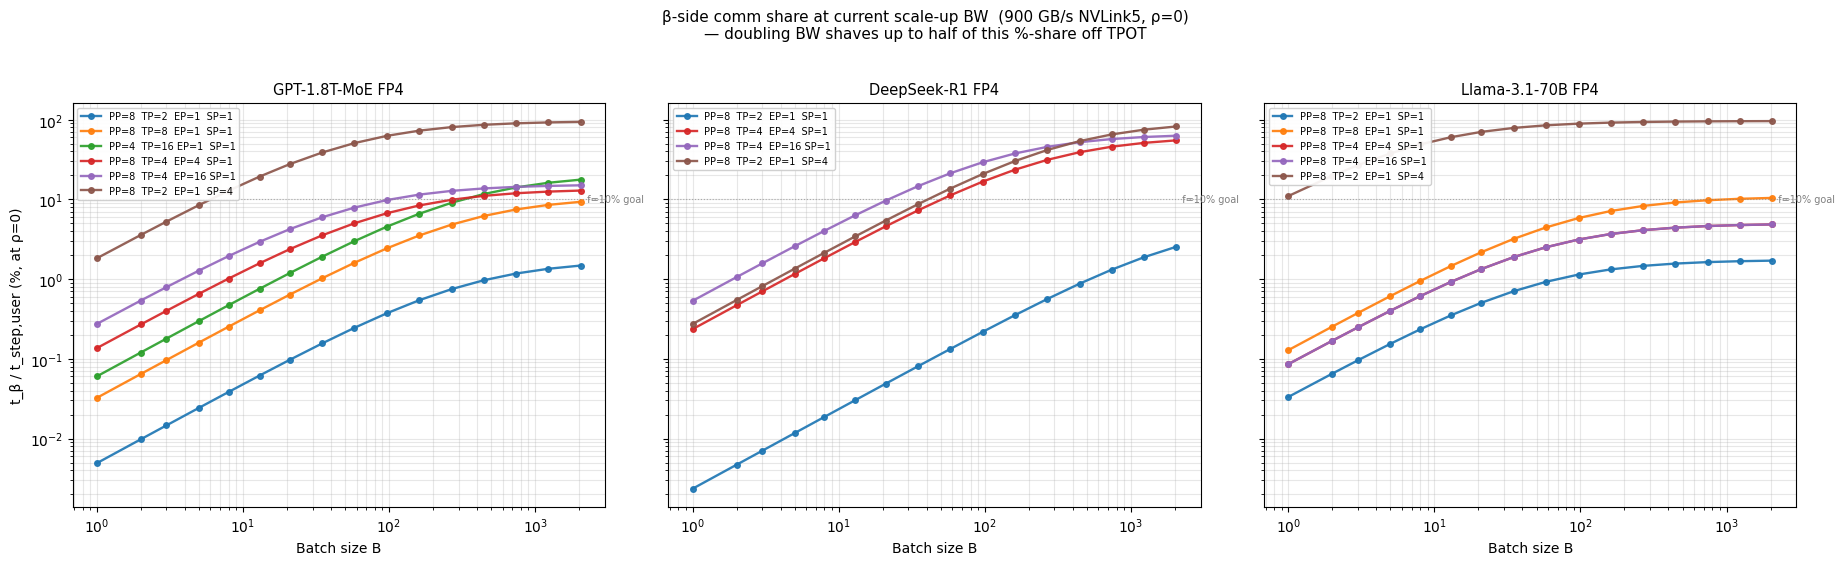

In [6]:
def t_step_no_overlap(model, p, B, n_TP, n_EP, n_SP, S, alpha_us, BW_mem_GBps, BW_GBps):
    """t_step at ρ=0 (no overlap). Approximation; ignores t_SW and t_LM
    surcharges — keeps the focus on the BW knob."""
    T_theta = per_device_T_theta(model, p)
    T_kv = per_request_T_KV(model, p, S)
    t_mem_us = (T_theta + B * T_kv) / (BW_mem_GBps * 1e9) * 1e6
    a = a_p_coef(model, p, n_TP, n_EP, n_SP)
    b_bytes = b_p_coef(model, p, B, n_TP, n_EP, n_SP, S)
    t_alpha_us = a * alpha_us
    t_beta_us = (b_bytes / (BW_GBps * 1e9)) * 1e6
    return t_mem_us + t_alpha_us + t_beta_us, t_beta_us


CURRENT_BW_GBps = 900.0  # NVLink5 reference

fig, axes = plt.subplots(1, len(loaded_models), figsize=(6.2 * len(loaded_models), 5.5),
                          sharey=True)
if len(loaded_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, loaded_models):
    for color_idx, (plabel, p) in enumerate(PARTITIONS):
        if not is_feasible(model, p):
            continue
        color = PARTITION_COLORS[color_idx % len(PARTITION_COLORS)]
        ratios = []
        for B in BATCH_SIZES:
            t_step, t_beta = t_step_no_overlap(model, p, int(B), N_TP_CALLS, N_EP_CALLS,
                                                N_SP_CALLS, S_DECODE, ALPHA_US,
                                                BW_MEM_GBps, CURRENT_BW_GBps)
            ratios.append(100.0 * t_beta / t_step)
        ax.plot(BATCH_SIZES, ratios, "-o", color=color, lw=1.7, ms=4,
                alpha=0.92, label=plabel)
    ax.axhline(10.0, color="gray", lw=0.8, ls=":", alpha=0.6)
    ax.text(BATCH_SIZES[-1], 10.0, "  f=10% goal", color="gray", fontsize=7, va="center", ha="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Batch size B")
    ax.set_title(name, fontsize=10.5)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left", fontsize=7, framealpha=0.92)

axes[0].set_ylabel("t_β / t_step,user (%, at ρ=0)")
fig.suptitle(
    f"β-side comm share at current scale-up BW  ({CURRENT_BW_GBps:.0f} GB/s NVLink5, ρ=0)\n"
    f"— doubling BW shaves up to half of this %-share off TPOT",
    fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig("assets/scale_up_io_bw_target_t_beta_share.png", dpi=140, bbox_inches="tight")
print("Saved -> assets/scale_up_io_bw_target_t_beta_share.png")
plt.show()


## 7. Frontier-shift check — does *BW*<sub>target</sub> for a chosen X actually move the Pareto frontier?

§4–§6 give per-partition thresholds. The Pareto frontier is cross-partition — picking BW = *BW*<sub>target</sub>(X) improves X's TPOT but only moves the frontier if X is on (or joins) the frontier under the new BW.

This cell takes a **chosen X**, computes its *BW*<sub>target</sub>(*f*, *B*) at a representative B, then sweeps all `PARTITIONS × BATCH_SIZES` at both **current BW** (NVL5 reference) and **new BW = *BW*<sub>target</sub>** to compare frontiers. The plot overlays the two frontiers and marks where X lives at each BW.

Read the result:
- If X's marker **on the new frontier** is at the upper-right of its old position → X improved AND the frontier improved through X.
- If the new frontier overlaps the old (no shift) → the optimizer was already routing around X; BW investment for X didn't help the frontier.
- If the new frontier shifts but X stays off → BW improvement helped *some* partition (different shape took over), but X-specific BW spend was redundant; you'd have gotten the same frontier from any BW upgrade.


Chosen X: DeepSeek-R1 FP4 / PP=8  TP=4  EP=4  SP=1 / B_ref=128
  BW_target(f=0.1) = 21,229 GB/s
  Current scale-up BW = 900 GB/s
  New BW for sweep    = 21,229 GB/s

Frontier sizes: current_BW = 16 pts, new_BW = 16 pts
Chosen X on current-BW frontier: 2 corners
Chosen X on new-BW frontier:     0 corners



Saved -> assets/scale_up_io_frontier_shift.png


/var/folders/70/pjyr2y156kzbtry8pjq__6100000gn/T/ipykernel_13943/3164685913.py:103: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r[2], r[3], color="red", s=180, marker=marker, zorder=6,


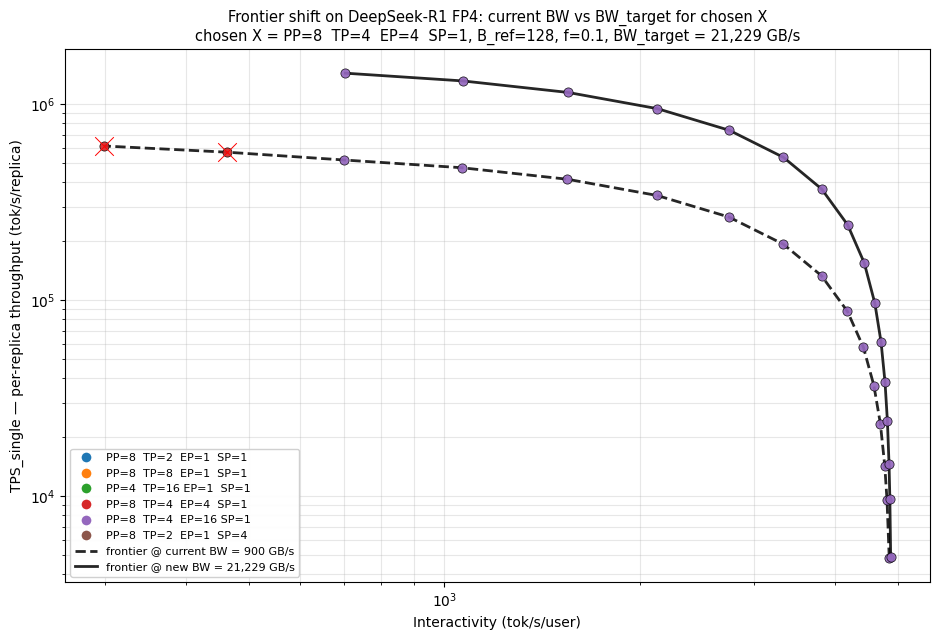

In [7]:
# Pick a chosen X (model + partition + reference B for BW_target derivation).
CHOSEN_MODEL_NAME = "DeepSeek-R1 FP4"
CHOSEN_PARTITION_LABEL = "PP=8  TP=4  EP=4  SP=1"
B_REF_FOR_BW_TARGET = 128
F_REF = 0.10

current_bw_GBps = 900.0  # NVL5 reference

chosen_model = next(m for n, m in loaded_models if n == CHOSEN_MODEL_NAME)
chosen_partition = next(p for label, p in PARTITIONS if label == CHOSEN_PARTITION_LABEL)

bw_target_chosen = bw_target(
    chosen_model, chosen_partition, B_REF_FOR_BW_TARGET, F_REF,
    ALPHA_US, BW_MEM_GBps, S_DECODE, N_TP_CALLS, N_EP_CALLS, N_SP_CALLS,
)
print(f"Chosen X: {CHOSEN_MODEL_NAME} / {CHOSEN_PARTITION_LABEL} / B_ref={B_REF_FOR_BW_TARGET}")
print(f"  BW_target(f={F_REF}) = {bw_target_chosen:,.0f} GB/s")
print(f"  Current scale-up BW = {current_bw_GBps:,.0f} GB/s")
new_bw_GBps = max(current_bw_GBps, bw_target_chosen)
print(f"  New BW for sweep    = {new_bw_GBps:,.0f} GB/s")
print()


def step_user_at_bw(model, p, B, BW_GBps, alpha_us, BW_mem_GBps, S, n_TP, n_EP, n_SP, rho=0.0):
    """t_step,user proxy at given scale-up BW. ρ=0 by default (additive comm,
    matching the tuner JSON). Ignores t_SW and t_LM surcharges to keep the
    focus on the BW-knob effect on t_comm."""
    T_theta = per_device_T_theta(model, p)
    T_kv = per_request_T_KV(model, p, S)
    t_mem_us = (T_theta + B * T_kv) / (BW_mem_GBps * 1e9) * 1e6
    a = a_p_coef(model, p, n_TP, n_EP, n_SP)
    b_bytes = b_p_coef(model, p, B, n_TP, n_EP, n_SP, S)
    t_comm_us = a * alpha_us + (b_bytes / (BW_GBps * 1e9)) * 1e6
    t_local_us = t_mem_us
    unhidden = max(0.0, t_comm_us - rho * t_local_us)
    return t_local_us + unhidden


def frontier_at_bw(model, BW_GBps, n_TP, n_EP, n_SP):
    """Build (1/TPOT, B/TPOT) cloud and extract upper-right envelope.
    Returns list of (label, B, interactivity, tput) for frontier points."""
    cloud = []
    for plabel, p in PARTITIONS:
        if not is_feasible(model, p):
            continue
        replica = max(1, p.PP) * max(1, p.TP) * max(1, p.EP) * max(1, p.SP)
        for B in BATCH_SIZES:
            B = int(B)
            t_step_us = step_user_at_bw(
                model, p, B, BW_GBps, ALPHA_US, BW_MEM_GBps, S_DECODE,
                n_TP, n_EP, n_SP,
            )
            interact = 1e6 / t_step_us         # tok/s/user
            tput_per_replica = B * interact     # tok/s/replica
            cloud.append((plabel, B, interact, tput_per_replica, replica))
    # Pareto envelope: sort by descending tput, keep strictly-improving interact
    cloud_sorted = sorted(cloud, key=lambda r: (-r[3], -r[2]))
    frontier = []
    best_interact = -1.0
    for r in cloud_sorted:
        if r[2] > best_interact + 1e-9:
            frontier.append(r); best_interact = r[2]
    frontier.sort(key=lambda r: r[3])
    return frontier


fr_old = frontier_at_bw(chosen_model, current_bw_GBps, N_TP_CALLS, N_EP_CALLS, N_SP_CALLS)
fr_new = frontier_at_bw(chosen_model, new_bw_GBps, N_TP_CALLS, N_EP_CALLS, N_SP_CALLS)
print(f"Frontier sizes: current_BW = {len(fr_old)} pts, new_BW = {len(fr_new)} pts")

# Did the chosen X join the frontier at new BW?
x_on_new = sum(1 for r in fr_new if r[0] == CHOSEN_PARTITION_LABEL)
x_on_old = sum(1 for r in fr_old if r[0] == CHOSEN_PARTITION_LABEL)
print(f"Chosen X on current-BW frontier: {x_on_old} corners")
print(f"Chosen X on new-BW frontier:     {x_on_new} corners")
print()


# Plot overlay
fig, ax = plt.subplots(figsize=(9.5, 6.5))

# Color points by partition shape
plabel_to_color = {plabel: PARTITION_COLORS[i % len(PARTITION_COLORS)]
                   for i, (plabel, _) in enumerate(PARTITIONS)}

# Frontier curves
for fr, ls, lw_label in [(fr_old, "--", f"current BW = {current_bw_GBps:.0f} GB/s"),
                          (fr_new, "-",  f"new BW = {new_bw_GBps:,.0f} GB/s")]:
    if not fr:
        continue
    xs = [r[2] for r in fr]
    ys = [r[3] for r in fr]
    ax.plot(xs, ys, ls, color="black", lw=2.0, alpha=0.85, label=f"frontier @ {lw_label}")
    # Mark points by partition color
    for r in fr:
        ax.scatter(r[2], r[3], color=plabel_to_color[r[0]], s=44, alpha=0.92,
                   edgecolor="black", linewidth=0.5, zorder=4)

# Highlight chosen X's frontier appearances
for fr, marker in [(fr_old, "x"), (fr_new, "*")]:
    for r in fr:
        if r[0] == CHOSEN_PARTITION_LABEL:
            ax.scatter(r[2], r[3], color="red", s=180, marker=marker, zorder=6,
                       edgecolor="black", linewidth=0.7,
                       label=f"chosen X on {'old' if marker=='x' else 'new'} frontier"
                       if r[1] == fr[0][1] else None)

# Legend for partition colors
legend_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                              markersize=8, label=l) for l, c in plabel_to_color.items()]
ax.legend(handles=legend_handles + ax.get_legend_handles_labels()[0],
          loc="lower left", fontsize=8, framealpha=0.92)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("TPS_single — per-replica throughput (tok/s/replica)")
ax.set_title(
    f"Frontier shift on {CHOSEN_MODEL_NAME}: current BW vs BW_target for chosen X\n"
    f"chosen X = {CHOSEN_PARTITION_LABEL}, B_ref={B_REF_FOR_BW_TARGET}, f={F_REF}, "
    f"BW_target = {bw_target_chosen:,.0f} GB/s",
    fontsize=10.5,
)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("assets/scale_up_io_frontier_shift.png", dpi=140, bbox_inches="tight")
print("Saved -> assets/scale_up_io_frontier_shift.png")
plt.show()


## 6. Discussion

Read the *BW*<sub>target</sub> plot first (§4) to find which (model, partition, *B*) cells need more bandwidth than current fabrics provide. Then read the *t*<sub>β</sub>-share plot (§5) to estimate the actual TPOT savings from BW doubling.

Patterns the sweep exposes:
- **PP=8 small-TP shapes** keep *BW*<sub>target</sub> well below NVL5's 900 GB/s even at the PP=8 cap — extra bandwidth is wasted on these PP-capped winners.
- **Wide TP=16** lifts *BW*<sub>target</sub> sharply at large *B* — and breaks "unreachable" at small *B* because *a*<sub>p</sub> · α exceeds the *f* · *t*<sub>mem</sub> budget.
- **High-EP MoE shapes** (EP=4 / EP=16) live in the unreachable-at-small-*B* regime; *f* = 0.25 is more often achievable than *f* = 0.1.
- **SP=4 ring-attention** drives *BW*<sub>target</sub> into TB/s territory — the only configuration where current BW is structurally under-provisioned.

To re-run with INC modeling, edit `a_p_coef` to substitute *n*<sub>α</sub> = 2*k* (k = number of switching tiers crossed) for the TP and SP axes — see explainer "If I have INC, can I assume tiny *a*<sub>p</sub>?" for the per-axis substitution rules.
